In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [31]:

file_path = os.path.join('..', 'data', 'raw', 'newsData','raw_analyst_ratings.csv')
news_df=pd.read_csv(file_path)
news_df.head()
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


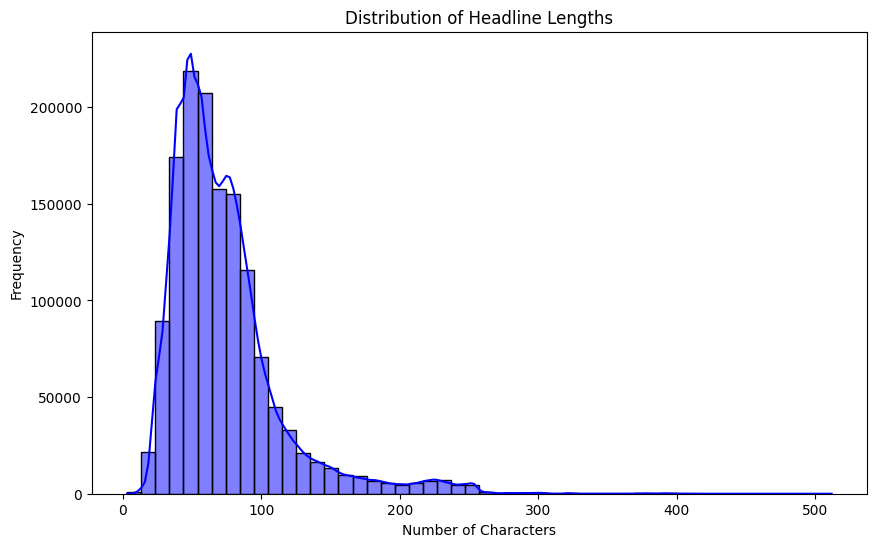

In [26]:
#Descriptive Statistics
#Calculate Headline Lengths
news_df['headline_len'] = news_df['headline'].apply(len)

print("Headline Length Statistics:")
print(news_df['headline_len'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(news_df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

Top 10 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


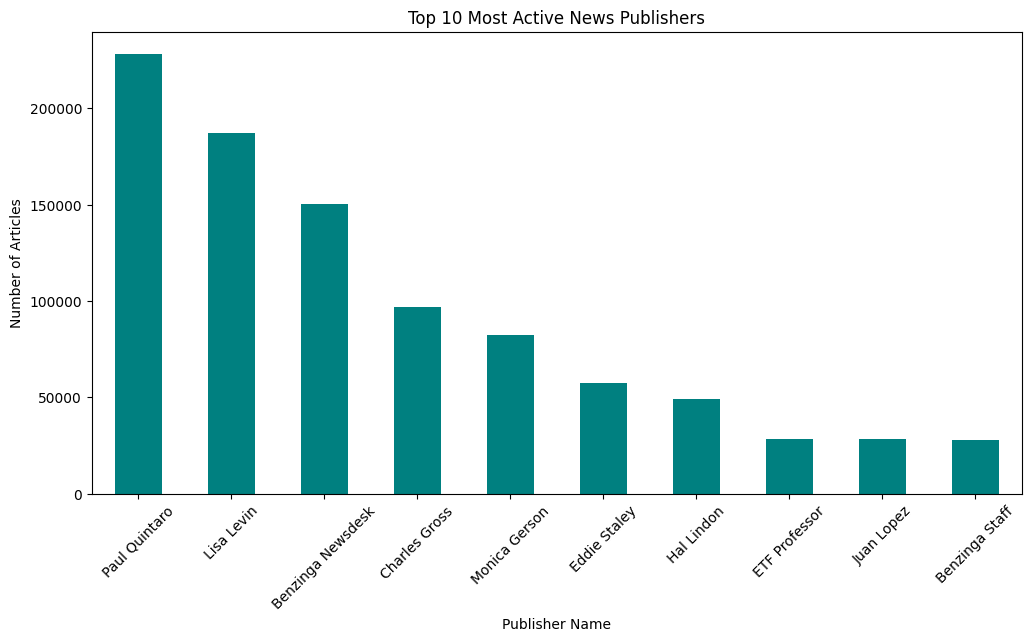

In [27]:
publisher_counts = news_df['publisher'].value_counts()

# 2. Get the top 10 most active publishers
top_10_publishers = publisher_counts.head(10)

print("Top 10 Publishers:")
print(top_10_publishers)

plt.figure(figsize=(12, 6))
top_10_publishers.plot(kind='bar', color='teal')
plt.title('Top 10 Most Active News Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

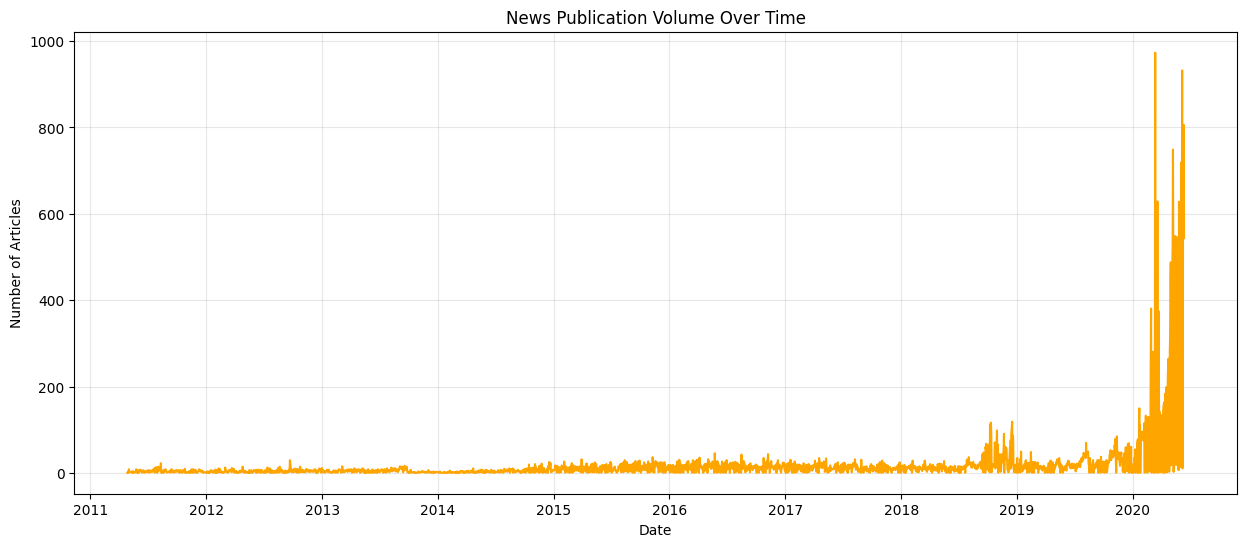

In [28]:
# 1. Convert the 'date' column to datetime objects
# Note: errors='coerce' turns unparseable dates into NaT (Not a Time)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# 2. Remove rows where the date couldn't be parsed (if any)
news_df = news_df.dropna(subset=['date'])

# 3. Extract just the date (ignoring the time) to see daily volume
news_df['only_date'] = news_df['date'].dt.date
daily_news_counts = news_df.groupby('only_date').size()

# 4. Visualize the News Volume Spike over time
plt.figure(figsize=(15, 6))
daily_news_counts.plot(kind='line', color='orange')
plt.title('News Publication Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()